# 작업 2.1 양자 회로 시각화 (Visualize Quantum Circuits)

## 목표: 양자 회로 시각화 (Visualize Quantum Circuits)

**개요:** 이 노트북은 양자 회로를 시각화하는 방법을 다룹니다.

Qiskit의 내장 시각화 도구를 사용하여 양자 회로를 시각화하는 다양한 방법이 있습니다. 적절한 시각화는 회로 구조를 이해하고, 디버깅하며, 양자 알고리즘을 프레젠테이션하는 데 도움이 됩니다.

- [overview](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit#quantum-circuit-model) : qiskit circuit의 Module overview
- [visualize circuits](https://quantum.cloud.ibm.com/docs/en/guides/visualize-circuits) : circuit visualization 관련 docs
- [circuit details](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.circuit_drawer) : qiskit visualization 함수에 사용할 수 있는 파라미터 관련 설명 docs

In [1]:
# 설정: 필요한 라이브러리 가져오기
import numpy as np
from qiskit import QuantumCircuit,QuantumRegister, ClassicalRegister

print("라이브러리를 성공적으로 가져왔습니다.")

라이브러리를 성공적으로 가져왔습니다.


## 기본 회로 생성 및 텍스트 시각화 (Basic Circuit Creation and Text Visualization)

간단한 양자 회로를 생성하고 이를 텍스트 형식으로 시각화하는 것부터 시작해 보겠습니다.

In [2]:
# 3개의 양자 비트와 3개의 클래식 비트로 양자 회로 구축
circuit = QuantumCircuit(3, 3)

# 양자 게이트 추가
circuit.h(0)                    # 큐비트 1에 Pauli-X (NOT) 게이트 적용
circuit.cx(0, 1)                # control=0, target=1인 CNOT 게이트 적용
circuit.cx(0, 2)                # control=0, target=2인 CNOT 게이트 적용
                
circuit.measure(range(3), range(3))  # 모든 큐비트를 클래식 비트로 측정

print("회로의 텍스트 표현:")
print(circuit)

회로의 텍스트 표현:
     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


## 기본 그리기 (텍스트 기반) (Default Drawing (Text-based))

매개변수 없이 `draw()` 메서드를 사용하면 회로를 표현하는 데 동일한 텍스트 형식을 사용합니다. 이는 터미널 환경에서 빠른 디버깅을 위해 유용합니다. 

In [3]:
# 기본 텍스트 기반 회로 그리기
print("텍스트 표현:")
circuit.draw()

텍스트 표현:


┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2

## 기타 시각화 (Other Visualizations)

출판물 품질의 회로 다이어그램을 위해 두 가지 대안이 있습니다. 하나는 `mpl` (Matplotlib) 출력입니다. 이는 적절한 간격과 스타일링이 적용된 깔끔하고 전문적인 시각화를 제공합니다. 다른 하나는 `latex` (LaTeX) 출력입니다. 하지만 이는 별도의 패키지 설치가 필요합니다. 

Matplotlib 기반 시각화:


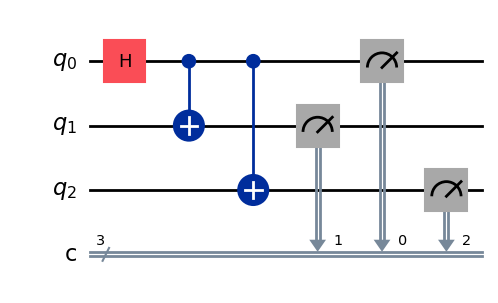

In [4]:
# matplotlib를 사용한 고품질 시각화
print("Matplotlib 기반 시각화:")
circuit.draw(output="mpl")

## latex 사용 

### (macos): brew install poppler

Latex 기반 시각화:


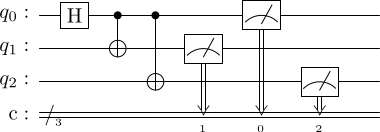

In [5]:
# latex를 사용한 고품질 시각화
print("Latex 기반 시각화:")
circuit.draw(output="latex")


In [6]:
# latex code 출력 -> 논문 등의 latex 사용시 유용
print("latex_source 출력:")
circuit.draw(output="latex_source")


latex_source 출력:


'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{\n\\Qcircuit @C=1.0em @R=0.2em @!R { \\\\\n\t \t\\nghost{{q}_{0} :  } & \\lstick{{q}_{0} :  } & \\gate{\\mathrm{H}} & \\ctrl{1} & \\ctrl{2} & \\qw & \\meter & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1} :  } & \\lstick{{q}_{1} :  } & \\qw & \\targ & \\qw & \\meter & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{2} :  } & \\lstick{{q}_{2} :  } & \\qw & \\qw & \\targ & \\qw & \\qw & \\meter & \\qw & \\qw\\\\\n\t \t\\nghost{\\mathrm{{c} :  }} & \\lstick{\\mathrm{{c} :  }} & \\lstick{/_{_{3}}} \\cw & \\cw & \\cw & \\dstick{_{_{\\hspace{0.0em}1}}} \\cw \\ar @{<=} [-2,0] & \\dstick{_{_{\\hspace{0.0em}0}}} \\cw \\ar @{<=} [-3,0] & \\dstick{_{_{\\hspace{0.0em}2}}} \\cw \\ar @{<=} [-1,0] & \\cw & \\cw\\\\\n\\\\ }}\n\\end{document}'

### 출력 저장하기 (Saving the output)

출력 이미지는 파일로 직접 저장할 수 있으며 나중에 이미지 뷰어에서 볼 수 있습니다.

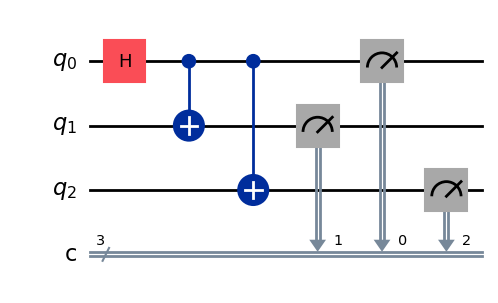

In [7]:
# 이미지 저장
circuit.draw(output="mpl", filename="circuit.jpeg")

## 더 복잡한 회로 (More Complex Circuits)

양자 회로는 여러 개의 양자 및 클래식 레지스터(quantum and classical registers)를 가질 수 있습니다. 이 예제는 다음을 보여줍니다:
- 더 나은 조직화를 위한 명명된 레지스터 (Named registers)
- 회로 섹션을 구분하기 위한 배리어(Barrier) 연산
- 서로 다른 레지스터에 걸친 측정 (Measurement)

여러 개의 장벽을 가진 회로:


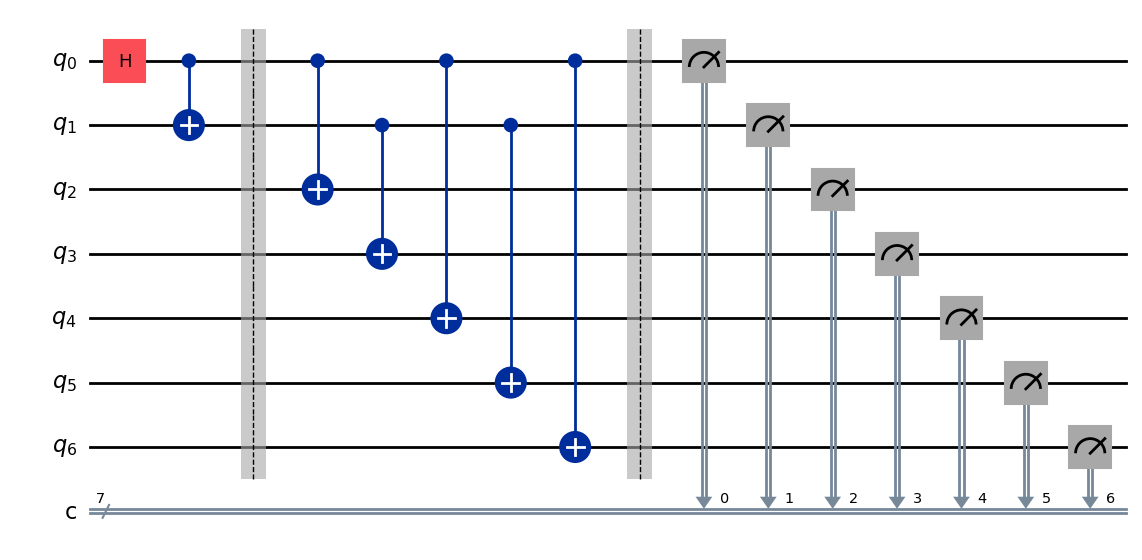

In [8]:
# 명명된 양자 및 클래식 레지스터 생성
qreg_q = QuantumRegister(7, 'q')    # 7개의 큐비트를 가진 양자 레지스터 'qreq_q'
creg_c = ClassicalRegister(7, 'c')  # 'creg_c' 측정을 위한 클래식 레지스터
 
# 더 복잡한 회로 구축
circuit = QuantumCircuit(qreg_q, creg_c)


circuit.h(qreg_q[0])                # 큐비트 0에 아다마르(Hadamard) 게이트 적용
circuit.cx(qreg_q[0], qreg_q[1])    # 큐비트 0과 1에 CNOT 게이트 적용
 
# 장벽(Barrier)
circuit.barrier()
 
circuit.cx(qreg_q[0], qreg_q[2])    # 큐비트 0과 2에 CNOT 게이트 적용
circuit.cx(qreg_q[1], qreg_q[3])    # 큐비트 1과 3에 CNOT 게이트 적용

circuit.cx(qreg_q[0], qreg_q[4])    # 큐비트 0과 4에 CNOT 게이트 적용
circuit.cx(qreg_q[1], qreg_q[5])    # 큐비트 1과 5에 CNOT 게이트 적용

circuit.cx(qreg_q[0], qreg_q[6])    # 큐비트 0과 6에 CNOT 게이트 적용

circuit.barrier()
# 측정 단계(Measurement phase)
circuit.measure(qreg_q, creg_c)     # 양자 레지스터 'qreg_q'를 클래식 레지스터 'creg_c'에 측정


# 전체 회로 그리기
print("여러 개의 장벽을 가진 회로:")
circuit.draw(output="mpl")

## 비트 순서 뒤집기 (Reverse Bit Order)

기본적으로 Qiskit은 리틀 엔디안(little-endian) 표기법을 사용합니다 (큐비트 0이 하단에 위치). `reverse_bits` 옵션은 서로 다른 관례나 개인적 선호에 맞춰 표시 순서를 변경합니다.

비트 순서가 뒤집힌 회로 (다이어그램 맨 아래에 큐비트 0 위치):


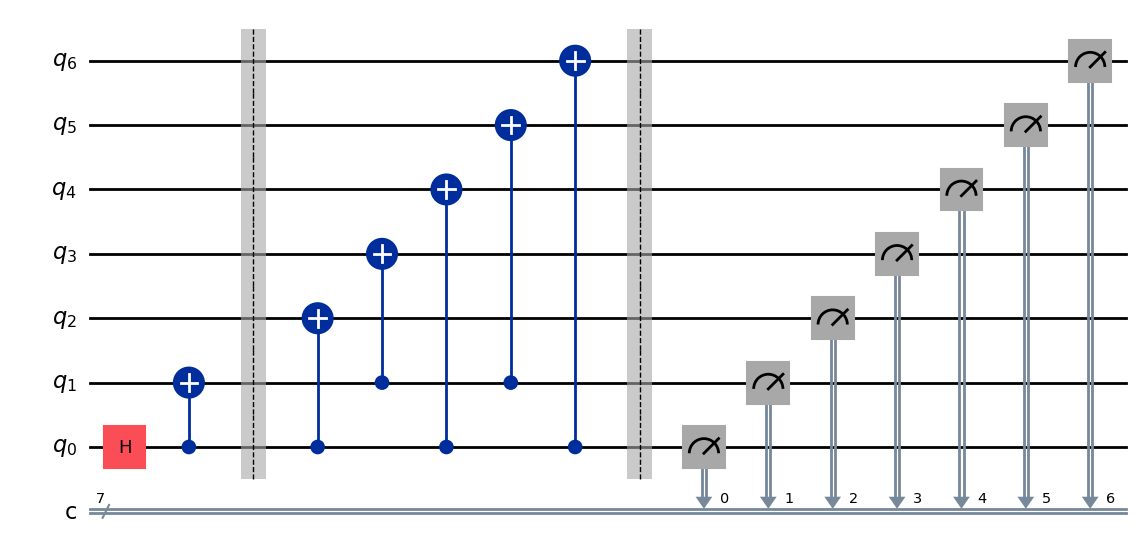

In [9]:
# 역순 비트 순서로 그리기 (빅 엔디안 스타일)
print("비트 순서가 뒤집힌 회로 (다이어그램 맨 아래에 큐비트 0 위치):")
circuit.draw(output="mpl", reverse_bits=True)

## 장벽 숨기기 (Hide Barriers)

장벽(Barrier)은 회로 컴파일 및 최적화에 유용하지만, 프레젠테이션이나 출판물에서 더 깔끔한 시각화를 위해 숨길 수 있습니다.

장벽이 숨겨진 회로 시각화:


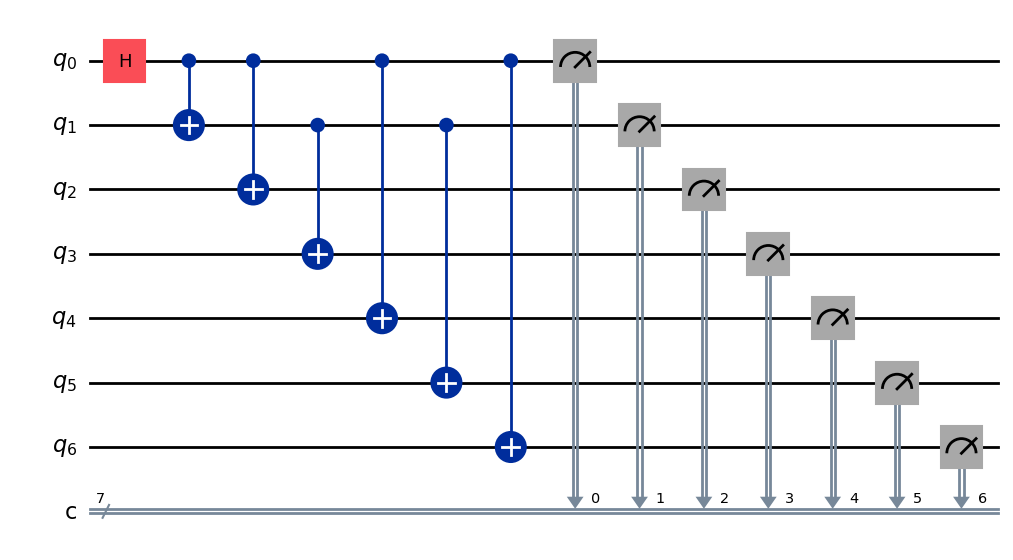

In [10]:
# 장벽 선 없이 그리기
print("장벽이 숨겨진 회로 시각화:")
circuit.draw(output="mpl", plot_barriers=False)

## 줄 바꿈이 포함된 텍스트 출력 (Text Output with Line Folding)

게이트가 많은 회로의 경우 텍스트 출력이 매우 넓어질 수 있습니다. `fold` 매개변수는 가독성을 높이기 위해 줄 길이를 제한합니다.

In [11]:
# 50자에서 줄 바꿈하여 표시
print("50자에서 줄 바꿈된 텍스트 출력:")
circuit.draw(output="text", fold=50)

50자에서 줄 바꿈된 텍스트 출력:


┌───┐      ░                           ░ ┌─┐»
q_0: ┤ H ├──■───░───■─────────■─────────■───░─┤M├»
     └───┘┌─┴─┐ ░   │         │         │   ░ └╥┘»
q_1: ─────┤ X ├─░───┼────■────┼────■────┼───░──╫─»
          └───┘ ░ ┌─┴─┐  │    │    │    │   ░  ║ »
q_2: ───────────░─┤ X ├──┼────┼────┼────┼───░──╫─»
                ░ └───┘┌─┴─┐  │    │    │   ░  ║ »
q_3: ───────────░──────┤ X ├──┼────┼────┼───░──╫─»
                ░      └───┘┌─┴─┐  │    │   ░  ║ »
q_4: ───────────░───────────┤ X ├──┼────┼───░──╫─»
                ░           └───┘┌─┴─┐  │   ░  ║ »
q_5: ───────────░────────────────┤ X ├──┼───░──╫─»
                ░                └───┘┌─┴─┐ ░  ║ »
q_6: ───────────░─────────────────────┤ X ├─░──╫─»
                ░                     └───┘ ░  ║ »
c: 7/══════════════════════════════════════════╩═»
                                               0 »
«                       
«q_0: ──────────────────
«     ┌─┐               
«q_1: ┤M├───────────────
«     └╥┘┌─┐            
«q_2: ─╫─┤M├────────────
«      ║ └╥┘┌─┐         
«q_3: ─╫──╫─┤M├─────────
«      ║  ║ └╥┘┌─┐      
«q_4: ─╫──╫──╫─┤M├──────
«      ║  ║  ║ └╥┘┌─┐   
«q_5: ─╫──╫──╫──╫─┤M├───
«      ║  ║  ║  ║ └╥┘┌─┐
«q_6: ─╫──╫──╫──╫──╫─┤M├
«      ║  ║  ║  ║  ║ └╥┘
«c: 7/═╩══╩══╩══╩══╩══╩═
«      1  2  3  4  5  6

fold=-1 옵션 사용 시:


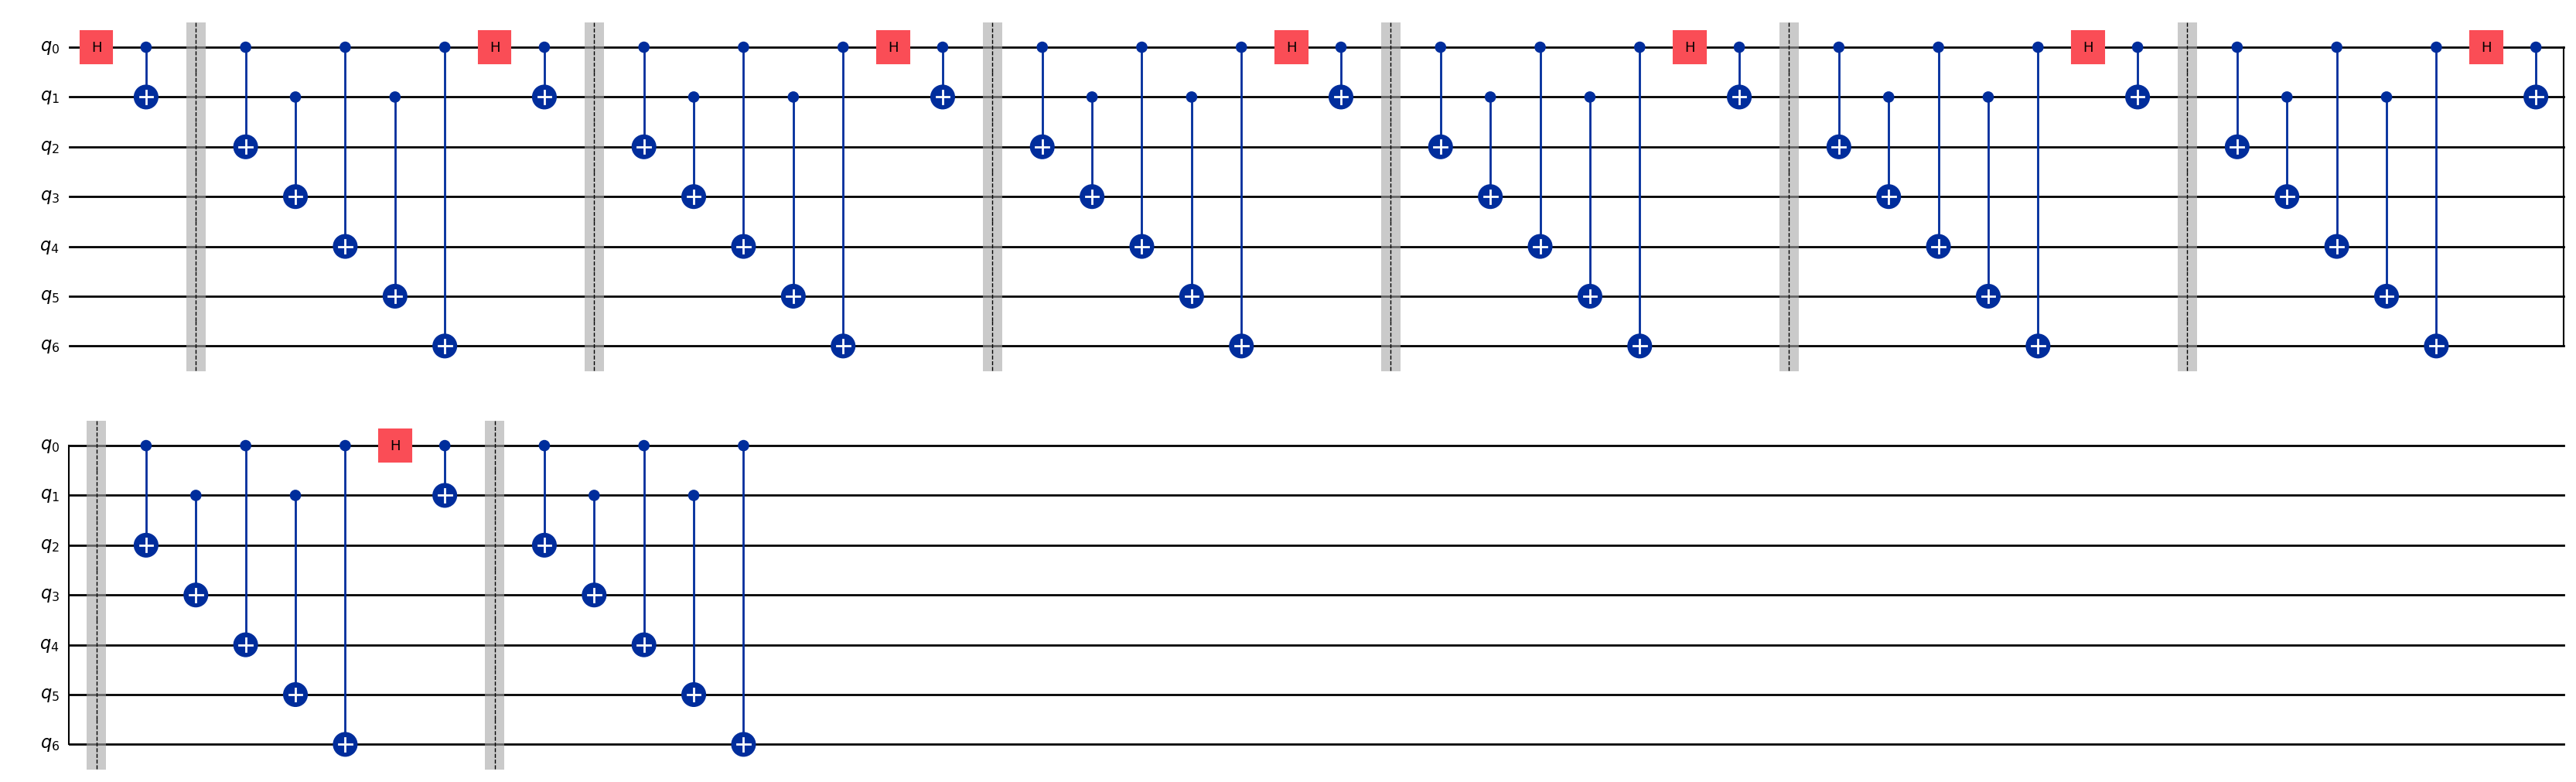

In [12]:
# fold=-1 사용 시 fold(회로 접기)를 끌 수도 있다.
print("fold=-1 옵션 사용 시:")
qc = circuit.copy()
qc.remove_final_measurements()
qc.compose(qc, inplace=True)
qc.compose(qc, inplace=True)
qc.compose(qc, inplace=True)
# qc.append(qc.to_gate()) # barrier 때문에 안됨 -> barrier를 제거해야 가능
qc.draw(output="mpl", fold=50)

fold=-1 옵션 사용 시:


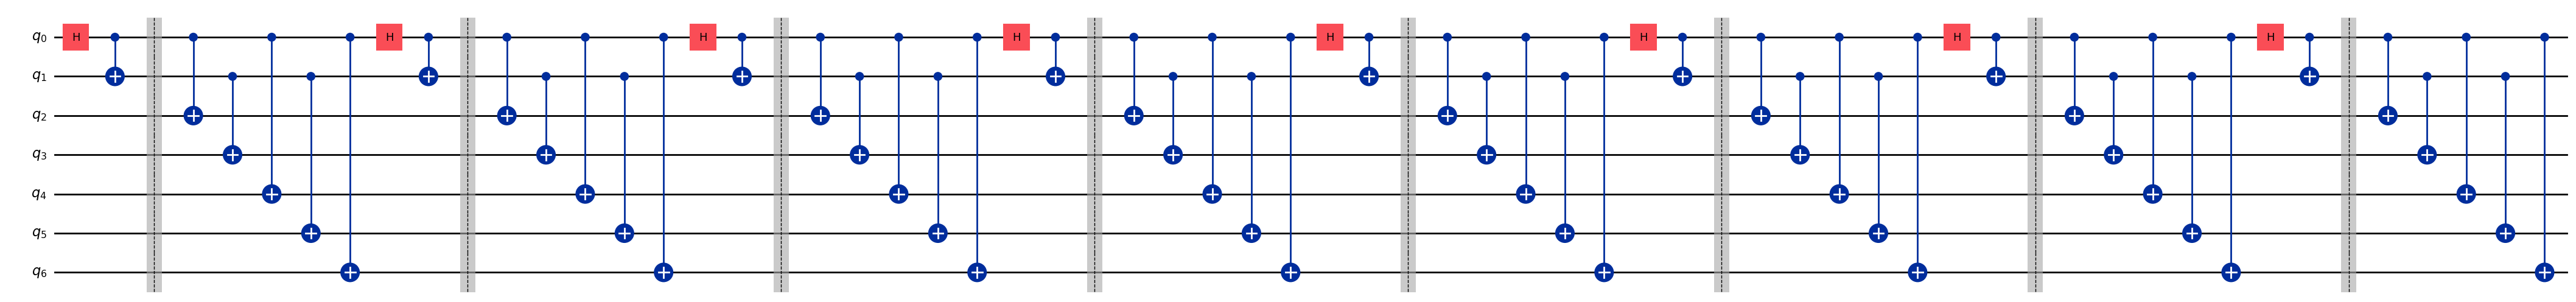

In [13]:
# fold=-1 사용 시 fold(회로 접기)를 끌 수도 있다.
print("fold=-1 옵션 사용 시:")
qc.draw(output="mpl", fold=-1)

## 스타일 지정 (Styling)

회로의 외관은 `draw()` 메서드의 `style` 매개변수를 사용하여 변경할 수 있습니다. 지원되는 스타일 이름은 "iqp", "iqp-dark", "clifford", "textbook" 및 "bw"입니다. JSON 파일을 사용할 수도 있지만 시각화 사양을 완벽하게 지정해야 합니다.

파일은 qiskit/visualization/circuit/styles, 현재 작업 디렉토리, 그리고 ~/.qiskit/settings.conf에 지정된 위치에서 검색됩니다.

흑백 스타일링이 적용된 회로:


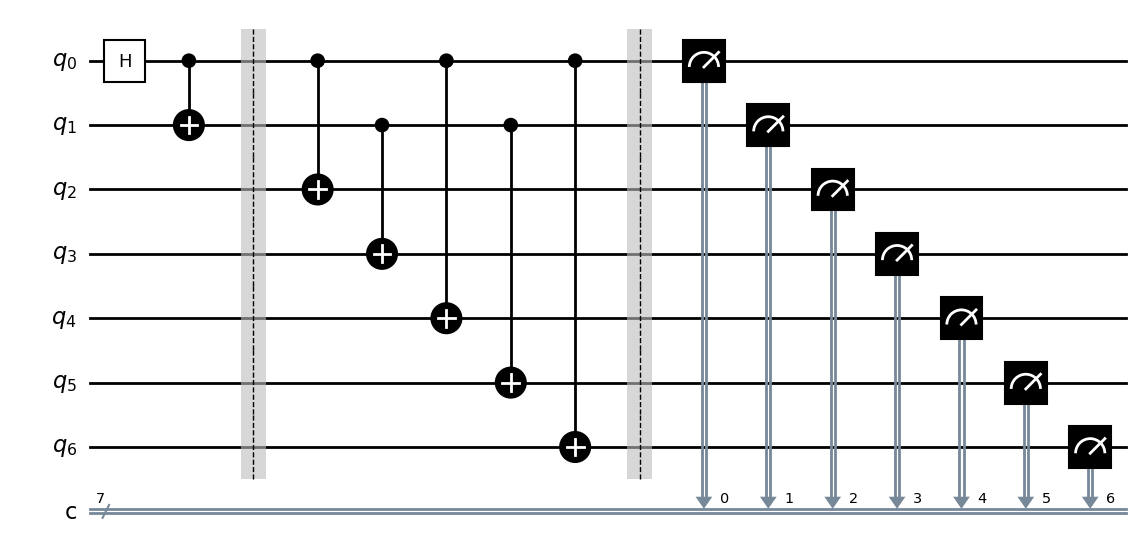

In [14]:
print("흑백 스타일링이 적용된 회로:")
circuit.draw(output="mpl", style="bw")

Qiskit은 스타일 딕셔너리(style dictionary)를 통한 광범위한 회로 외관 사용자 정의를 허용합니다. 이는 프리젠테이션, 교재 제작 또는 출판물 스타일을 맞추는 데 유용합니다.

사용자 정의 스타일링이 적용된 회로 (하늘색 배경):


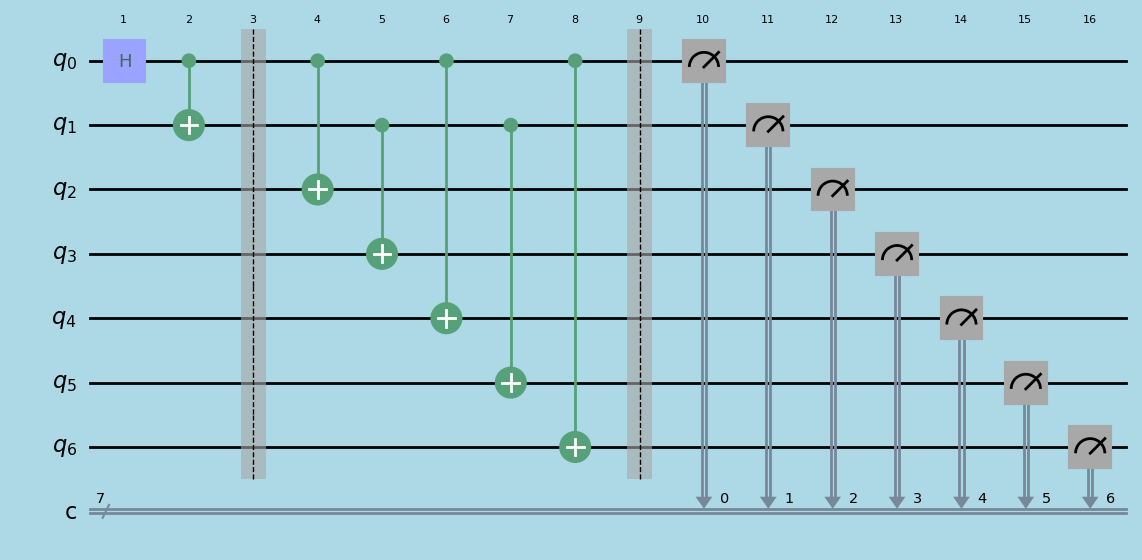

In [15]:
# 회로 외양을 위한 사용자 정의 스타일 딕셔너리
style = {
    "backgroundcolor": "lightblue",    # 배경색 변경
    "fold": 40,                         # 긴 회로 줄 바꿈
    "showindex": True,                  # 큐비트 인덱스 표시
    "compress": False,                  # 시각화 압축 방지
    "displaycolor": {                   # 아다마르(Hadamard) 게이트와 폰트 색상 변경
        "h": [
            "#9AA3FF",
            "#406B51"
        ],
        "cx": [
            "#56A179",
            "#DA8B4F"
        ]
    }
}

print("사용자 정의 스타일링이 적용된 회로 (하늘색 배경):")
circuit.draw(output="mpl", style=style)

## 크기 조절 (Scale Control)

디스플레이 크기나 문서의 제한 사항에 맞게 회로 다이어그램의 크기를 조절합니다.

정상 크기의 50%로 조절된 회로:


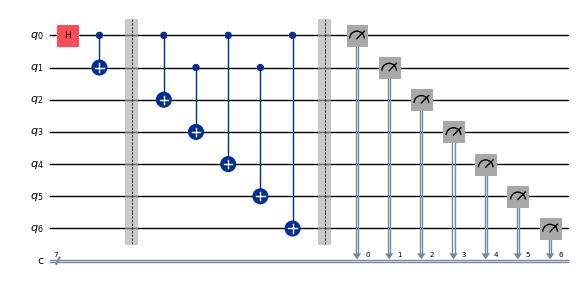

In [16]:
# 회로 크기를 정상 크기의 절반으로 조절
print("정상 크기의 50%로 조절된 회로:")
circuit.draw(output="mpl", scale=0.5)

## circuit_drawer 함수 사용하기 (Using circuit_drawer Function)

`draw()` 메서드의 대안으로 `circuit_drawer` 함수를 직접 사용할 수 있습니다. 두 가지 접근 방식 모두 동일한 기능을 제공합니다.

직접 circuit_drawer 함수 사용하기:


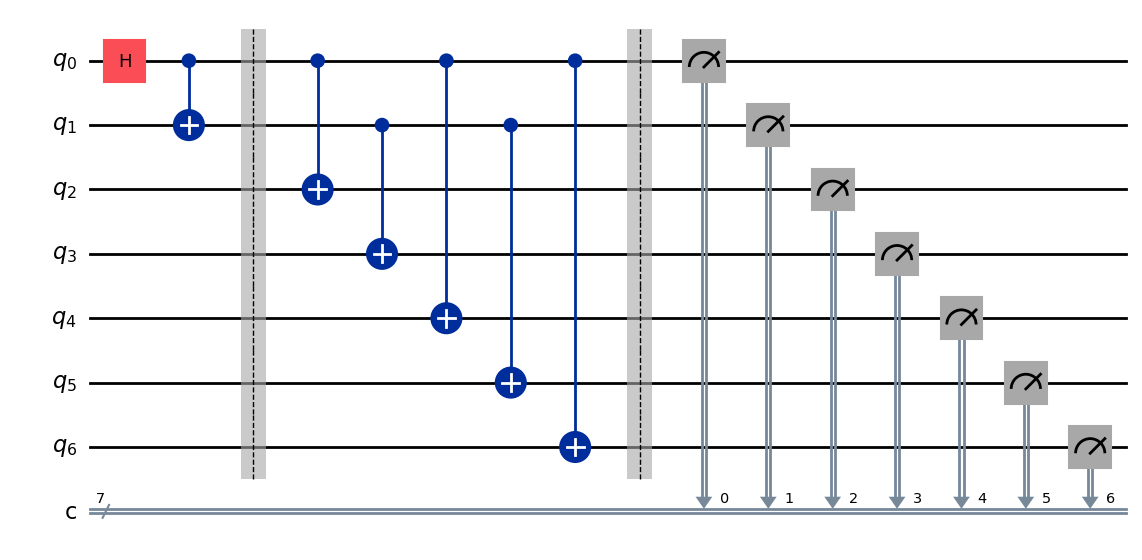

In [17]:
from qiskit.visualization import circuit_drawer
 
# 회로 그리기를 위한 함수형 인터페이스 사용
print("직접 circuit_drawer 함수 사용하기:")
circuit_drawer(circuit, output="mpl")

---
## 요약
---

이 노트북에서는 다음 내용을 다루었습니다:

## 양자 회로 시각화 (Quantum Circuit Visualizations):

1. 텍스트, mpl 또는 latex로 그릴 수 있으며 출력을 이미지로 저장할 수 있습니다.
2. 줄 바꿈(line folding), 비트 순서 뒤집기(reverse bits ordering), 배리어 숨기기, 사용자 정의 스타일링 및 스케일링과 같은 기능을 제공합니다.

---

## 연습 문제 (Practice Questions)

**1) draw() 메서드에서 큐비트 0을 다이어그램의 상단 대신 하단에 표시하는 데 사용되는 매개변수는 무엇입니까?**

A) vertical=True

B) qubit_order='reversed'

C) reverse_bits=True

D) little_endian=False

E) display_order='bottom'



***정답:***
<Details>
<br/>
C) reverse_bits= True는 비트 순서를 뒤집는 데 사용됩니다.
</Details>

---

**2) 회로 시각화 결과를 이미지 파일로 어떻게 내보낼 수 있습니까?**

A) ```circuit.draw('mpl').save('circuit.png')```

B)  ```circuit.draw(output="mpl", filename="circuit.jpeg")```

C) ```circuit.save('circuit.png')```

D) ```circuit.to_image('mpl')```


***정답:***
<Details>
<br/>
B) circuit.draw(output="mpl", filename="circuit-mpl.jpeg")
</Details>

---

**3) circuit.draw('mpl', style={'fontColor': '#000000'})를 호출하면 어떤 일이 발생합니까?**

A. 회로의 배경색이 검은색으로 변경됩니다

B. 큐비트 와이어 색상이 반전됩니다

C. 'fontColor'는 유효한 스타일 키가 아니므로 TypeError가 발생합니다

D. 출력이 자동으로 다크 모드로 전환됩니다


***정답:***
<Details>
<br/>
C) 'fontColor'는 유효한 스타일 키가 아니므로 TypeError가 발생합니다
</Details>